<a href="https://colab.research.google.com/github/WellingtonRoque/MineracaoDados/blob/main/atividades/aula8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aula 08 — Análise Exploratória de Dados (EDA)

🔎 Descobrindo padrões, comportamentos e anomalias nos dados

3. Preparando o ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Ambiente preparado!")

Ambiente preparado!


4. Criando nossa base de dados

Vamos criar uma base maior para permitir uma análise mais interessante.

Cada registro representa uma leitura de um motor.

Para facilitar a aula, vamos gerar dados simulados com características semelhantes às encontradas em sensores industriais.

In [9]:
import random

random.seed(42)

valores = [random.randint(1, 10) for _ in range(10)]

print(valores)

[2, 1, 5, 4, 4, 3, 2, 9, 2, 10]


In [13]:
np.random.seed(42)

n = 300

df = pd.DataFrame({
    "motor": np.random.choice(["M001", "M002", "M003", "M004", "M005"], n),
    "temperatura": np.random.normal(65, 8, n),
    "vibracao": np.random.normal(2.2, 0.7, n),
    "corrente": np.random.normal(13, 2, n),
    "tensao": np.random.normal(380, 4, n),
    "rpm": np.random.normal(1740, 15, n)
})

df.head()

,motor,temperatura,vibracao,corrente,tensao,rpm
0,M004,63.979162,1.590127,12.379309,377.934204,1739.724765
1,M005,67.732726,2.041275,13.231370,380.176975,1759.676759
2,M003,81.951090,1.660239,10.498007,375.050633,1725.769173
3,M005,77.372294,2.603322,18.211955,382.516996,1707.572318
4,M005,57.403848,3.032720,11.534120,380.763751,1745.496857


5. Primeira inspeção

A primeira pergunta é simples:

Quantos dados temos?

In [14]:
df.shape

(300, 6)

Agora vamos observar algumas linhas.

In [16]:
df.head(15)

,motor,temperatura,vibracao,corrente,tensao,rpm
0,M004,63.979162,1.590127,12.379309,377.934204,1739.724765
1,M005,67.732726,2.041275,13.231370,380.176975,1759.676759
2,M003,81.951090,1.660239,10.498007,375.050633,1725.769173
3,M005,77.372294,2.603322,18.211955,382.516996,1707.572318
4,M005,57.403848,3.032720,11.534120,380.763751,1745.496857
5,M002,60.224821,2.356335,12.277079,376.421747,1736.145683
6,M003,64.110368,2.252686,11.361471,376.475571,1755.162934
7,M003,51.007445,1.587494,14.231417,386.463834,1738.042274
8,M003,54.268772,1.708214,12.607995,387.886675,1730.934914
9,M005,52.026443,1.364718,11.072385,379.147459,1738.862739


E também as últimas linhas:

In [17]:
df.tail()


,motor,temperatura,vibracao,corrente,tensao,rpm
295,M005,66.019475,2.207944,13.355512,380.666611,1746.322102
296,M005,71.934793,2.386935,12.064574,381.300707,1746.710390
297,M003,68.768295,2.714117,16.582288,379.333104,1721.791089
298,M004,62.134326,2.001679,13.347816,383.235717,1769.158153
299,M001,72.214907,2.285438,15.178873,377.158190,1715.656331


6. Conhecendo as colunas

In [18]:
df.columns

Index(['motor', 'temperatura', 'vibracao', 'corrente', 'tensao', 'rpm'], dtype='object')

O info() ajuda a identificar:

* quantidade de registros;
* nomes das colunas;
* tipos de dados;
* valores não nulos.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   motor        300 non-null    object 
 1   temperatura  300 non-null    float64
 2   vibracao     300 non-null    float64
 3   corrente     300 non-null    float64
 4   tensao       300 non-null    float64
 5   rpm          300 non-null    float64
dtypes: float64(5), object(1)
memory usage: 14.2+ KB


7. Estatística descritiva

Vamos utilizar describe().

In [20]:
df.describe()

,temperatura,vibracao,corrente,tensao,rpm
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,64.647868,2.270386,13.244236,380.133357,1739.759461
std,8.502867,0.752530,2.198331,4.048832,14.136027
min,38.087236,0.250755,7.780316,369.939846,1689.725842
25%,58.954301,1.752061,11.740896,377.484449,1729.727682
50%,64.745526,2.284945,13.008021,380.272450,1740.479247
75%,70.922184,2.782558,14.681177,382.924584,1749.270181
max,90.496267,4.283338,19.334743,390.798857,1771.934198


8. Média, mediana e moda
A média é conhecida, mas não é suficiente.

Vamos calcular média e mediana da temperatura.

In [21]:
media = df["temperatura"].mean()
mediana = df["temperatura"].median()

print("Média:", media)
print("Mediana:", mediana)

Média: 64.64786813129498
Mediana: 64.7455264157538


In [26]:
df["motor"].mode()

,motor
0,M004


In [23]:
df["motor"].value_counts()

,count
motor,
M004,74
M001,69
M003,63
M005,48
M002,46


9. Distribuição da temperatura

Vamos visualizar como as temperaturas estão distribuídas.

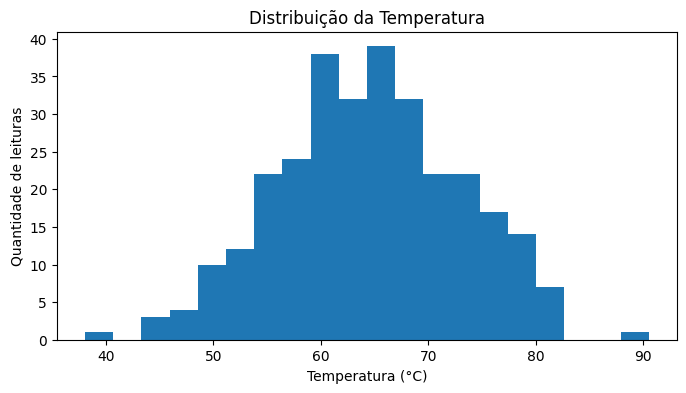

In [27]:

plt.figure(figsize=(8, 4))
plt.hist(df["temperatura"], bins=20)
plt.title("Distribuição da Temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Quantidade de leituras")
plt.show()

10. Boxplot

Outra visualização muito importante é o boxplot.

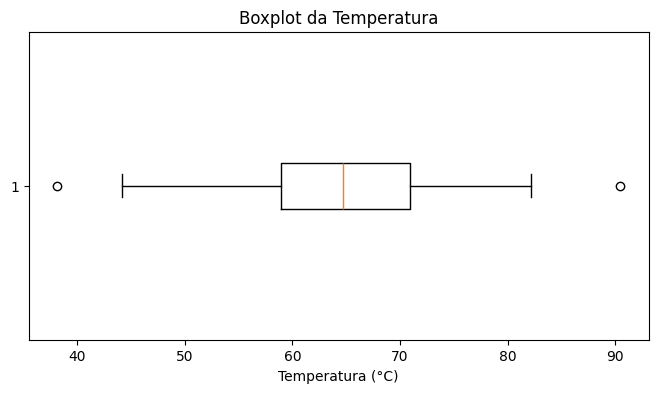

In [28]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["temperatura"], vert=False)
plt.title("Boxplot da Temperatura")
plt.xlabel("Temperatura (°C)")
plt.show()

11. Investigando valores extremos

Vamos localizar registros com temperatura acima de 85 °C.

In [33]:
df[df["temperatura"] > 80].sort_values("temperatura", ascending=False).head(50)

,motor,temperatura,vibracao,corrente,tensao,rpm
68,M004,90.496267,2.572342,18.003396,380.358433,1733.637015
127,M004,82.145642,1.149185,16.693612,377.655772,1752.724943
52,M004,82.077130,3.646931,11.093082,385.352461,1734.750328
2,M003,81.951090,1.660239,10.498007,375.050633,1725.769173
64,M002,81.904897,1.844116,13.937127,380.011129,1730.968420
259,M002,81.257140,2.379997,9.919163,375.888389,1723.220710
27,M002,81.002785,1.318811,13.970350,382.028063,1738.238987
283,M004,80.787687,1.707005,14.991097,374.767806,1724.862626


Agora vamos contar quantos registros ultrapassam esse limite.

In [35]:
quantidade = (df["temperatura"] > 75).sum()

print("Quantidade de registros:", quantidade)

Quantidade de registros: 38


12. Comparando motores

Queremos descobrir se alguns motores trabalham em temperaturas maiores.

In [36]:
temperatura_motor = (
    df.groupby("motor")["temperatura"]
      .agg(["count", "mean", "min", "max"])
      .sort_values("mean", ascending=False)
)

temperatura_motor

,count,mean,min,max
motor,,,,
M003,63,66.126524,51.007445,81.951090
M004,74,64.841631,38.087236,90.496267
M001,69,64.281441,49.928932,78.389985
M002,46,63.946177,45.326453,81.904897
M005,48,63.607607,46.966731,78.402346


13. Gráfico por motor

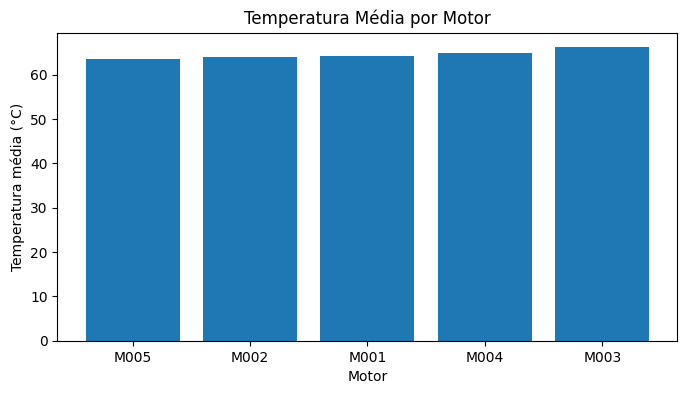

In [37]:
media_motor = df.groupby("motor")["temperatura"].mean().sort_values()

plt.figure(figsize=(8, 4))
plt.bar(media_motor.index, media_motor.values)
plt.title("Temperatura Média por Motor")
plt.xlabel("Motor")
plt.ylabel("Temperatura média (°C)")
plt.show()

14. Relação entre duas variáveis

Agora queremos investigar:

A vibração aumenta quando a temperatura aumenta?

Para isso podemos utilizar um gráfico de dispersão.

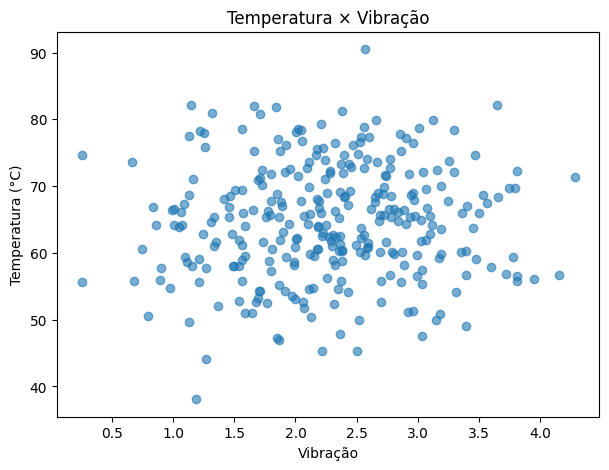

In [38]:
plt.figure(figsize=(7, 5))
plt.scatter(df["vibracao"], df["temperatura"], alpha=0.6)
plt.title("Temperatura × Vibração")
plt.xlabel("Vibração")
plt.ylabel("Temperatura (°C)")
plt.show()

15. Correlação

A correlação mede o grau de associação linear entre duas variáveis.

Vamos calcular a matriz de correlação.

In [39]:
correlacao = df.select_dtypes(include="number").corr()

correlacao

,temperatura,vibracao,corrente,tensao,rpm
temperatura,1.000000,0.060580,0.133466,-0.027725,-0.116533
vibracao,0.060580,1.000000,0.043799,-0.075018,-0.078440
corrente,0.133466,0.043799,1.000000,-0.098338,-0.011015
tensao,-0.027725,-0.075018,-0.098338,1.000000,0.018009
rpm,-0.116533,-0.078440,-0.011015,0.018009,1.000000


16. Visualizando a correlação

Vamos visualizar a matriz utilizando imshow().

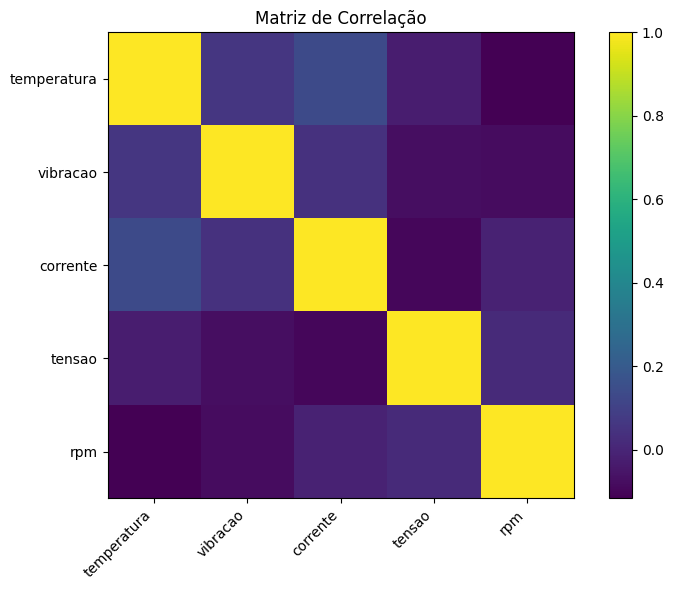

In [40]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de Correlação")
plt.colorbar()
plt.tight_layout()
plt.show()

In [41]:
df.isnull().sum()

,0
motor,0
temperatura,0
vibracao,0
corrente,0
tensao,0
rpm,0


19. Criando indicadores

EDA também pode ajudar a criar novas variáveis.

Por exemplo, podemos criar uma indicação simples de alerta térmico:

temperatura >= 80 → alerta

temperatura < 80 → normal

In [49]:
df["nivel_atencao"] = np.where(
    (df["temperatura"] >= 77) & (df["vibracao"] >= 3),
    "Alto",
    "Normal"
)

df["nivel_atencao"].value_counts()

,count
nivel_atencao,
Normal,296
Alto,4


Agora vamos investigar quais motores apresentam mais situações de atenção.

In [50]:
pd.crosstab(df["motor"], df["nivel_atencao"])

nivel_atencao,Alto,Normal
motor,,
M001,0,69
M002,0,46
M003,1,62
M004,2,72
M005,1,47
